In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')
import sys
sys.path.append(".")
from src.data_loader import run_query
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SNAPSHOT_DATE = "2018-08-29"  # max order date; recency measured from here

In [ ]:
rfm_sql = f"""
    WITH delivered AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            o.order_purchase_timestamp,
            SUM(oi.price + oi.freight_value) AS order_value
        FROM orders o
        JOIN customers c         ON o.customer_id = c.customer_id
        LEFT JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1, 2, 3
    )
    SELECT
        customer_unique_id,
        DATE_DIFF('day', MAX(order_purchase_timestamp), DATE '{SNAPSHOT_DATE}') AS recency_days,
        COUNT(DISTINCT order_id)                                                AS frequency,
        SUM(order_value)                                                        AS monetary,
        AVG(order_value)                                                        AS avg_order_value,
        MIN(order_purchase_timestamp)                                           AS first_purchase,
        MAX(order_purchase_timestamp)                                           AS last_purchase
    FROM delivered
    GROUP BY customer_unique_id
"""
rfm = run_query(rfm_sql)
print(rfm.head)
print(rfm.shape)
rfm.describe()

<bound method NDFrame.head of                      customer_unique_id  recency_days  frequency  monetary  \
0      639d23421f5517f69d0c3d6e6564cf0e           163          1    157.60   
1      7ed0ea20347f67fe61d1c99fdf8556ae            36          1     97.32   
2      9e4159995424971423b98c4a8bc11529           197          1    126.54   
3      6457be0b331148fb5454efc88d1e03d9           110          1    152.77   
4      f5f088001070650f9e9a8cd773621f35           382          1    112.71   
...                                 ...           ...        ...       ...   
93353  a1c2e4b4c1b29e41684ebdf3cc6538f8            47          1    181.10   
93354  a969e99358a58bed2f4073fd04165a2b           183          1    113.07   
93355  2ccfd5dc1ea812c6386a7a282e5bf180           327          1     95.69   
93356  c71a196d46a70ec611f3922db5755d1d           348          1    215.83   
93357  0e1dad535a5b2359a2ff0a7d475ffb86           278          1    101.73   

       avg_order_value      first

,recency_days,frequency,monetary,avg_order_value,first_purchase,last_purchase
count,93358.000000,93358.000000,93358.000000,93358.000000,93358,93358
mean,237.478877,1.033420,165.168210,160.287465,2018-01-01 12:18:32.380503,2018-01-04 03:47:36.045362
min,0.000000,1.000000,9.590000,9.590000,2016-09-15 12:16:38,2016-09-15 12:16:38
25%,114.000000,1.000000,63.010000,62.330000,2017-09-13 15:41:22.500000,2017-09-17 18:25:15
50%,218.000000,1.000000,107.780000,105.630000,2018-01-20 06:48:07,2018-01-23 00:12:12.500000
75%,346.000000,1.000000,182.510000,176.590000,2018-05-05 14:13:38.250000,2018-05-07 17:22:34.750000
max,713.000000,15.000000,13664.080000,13664.080000,2018-08-29 15:00:37,2018-08-29 15:00:37
std,152.595054,0.209097,226.292101,219.554565,NaN,NaN


In [ ]:
cust_ord_sql = """
    SELECT
    o.order_status,
    COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
    COUNT(*) AS orders
FROM orders o
JOIN customers c
  ON o.customer_id = c.customer_id
GROUP BY o.order_status
ORDER BY orders DESC;
"""
df = run_query(cust_ord_sql)
print(df.shape)
df.head(10)

(8, 3)


,order_status,unique_customers,orders
0,delivered,93358,96478
1,shipped,1100,1107
2,canceled,616,625
3,unavailable,604,609
4,invoiced,314,314
5,processing,301,301
6,created,5,5
7,approved,2,2


In [ ]:
rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
# Frequency: rank-based because >90% are tied at 1
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5,
                         labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm[["recency_days", "frequency", "monetary", "R_score", "F_score", "M_score", "RFM_score"]].head()

,recency_days,frequency,monetary,R_score,F_score,M_score,RFM_score
0,163,1,157.60,4,1,4,9
1,36,1,97.32,5,1,3,9
2,197,1,126.54,3,1,3,7
3,110,1,152.77,4,1,4,9
4,382,1,112.71,2,1,3,6


In [ ]:
cohort_sql = """
    WITH first_order AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    ),
    activity AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1, 2
    )
    SELECT
        f.cohort_month,
        DATE_DIFF('month', f.cohort_month, a.order_month) AS month_offset,
        COUNT(DISTINCT a.customer_unique_id)              AS active_customers
    FROM first_order f
    JOIN activity a ON f.customer_unique_id = a.customer_unique_id
    GROUP BY 1, 2
    ORDER BY 1, 2
"""
cohort_long = run_query(cohort_sql)
cohort_long.head(15)

,cohort_month,month_offset,active_customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1
5,2016-10-01,13,1
6,2016-10-01,15,1
7,2016-10-01,17,1
8,2016-10-01,19,2
9,2016-10-01,20,2


cohort_month = When the customer made their first-ever purchase.
month_offset = 0 = Customers who joined that month (the size of the cohort).
month_offset = 1 = How many of those same customers returned one month later.
month_offset = 2 = How many returned two months later.

In [ ]:
# Pivot to counts
cohort_counts = cohort_long.pivot(index="cohort_month",
                                  columns="month_offset",
                                  values="active_customers")

# Cohort size = month_offset 0
cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention.iloc[:5, :6]  # peek at the triangle

month_offset,0,1,2,3,4,5
cohort_month,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN
2016-12-01,100.0,100.000000,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.278940,0.278940,0.13947,0.418410,0.13947
2017-02-01,100.0,0.184275,0.307125,0.12285,0.429975,0.12285


In [ ]:
cohort_counts.iloc[:5, :6]

month_offset,0,1,2,3,4,5
cohort_month,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN
2016-10-01,262.0,NaN,NaN,NaN,NaN,NaN
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN
2017-01-01,717.0,2.0,2.0,1.0,3.0,1.0
2017-02-01,1628.0,3.0,5.0,2.0,7.0,2.0


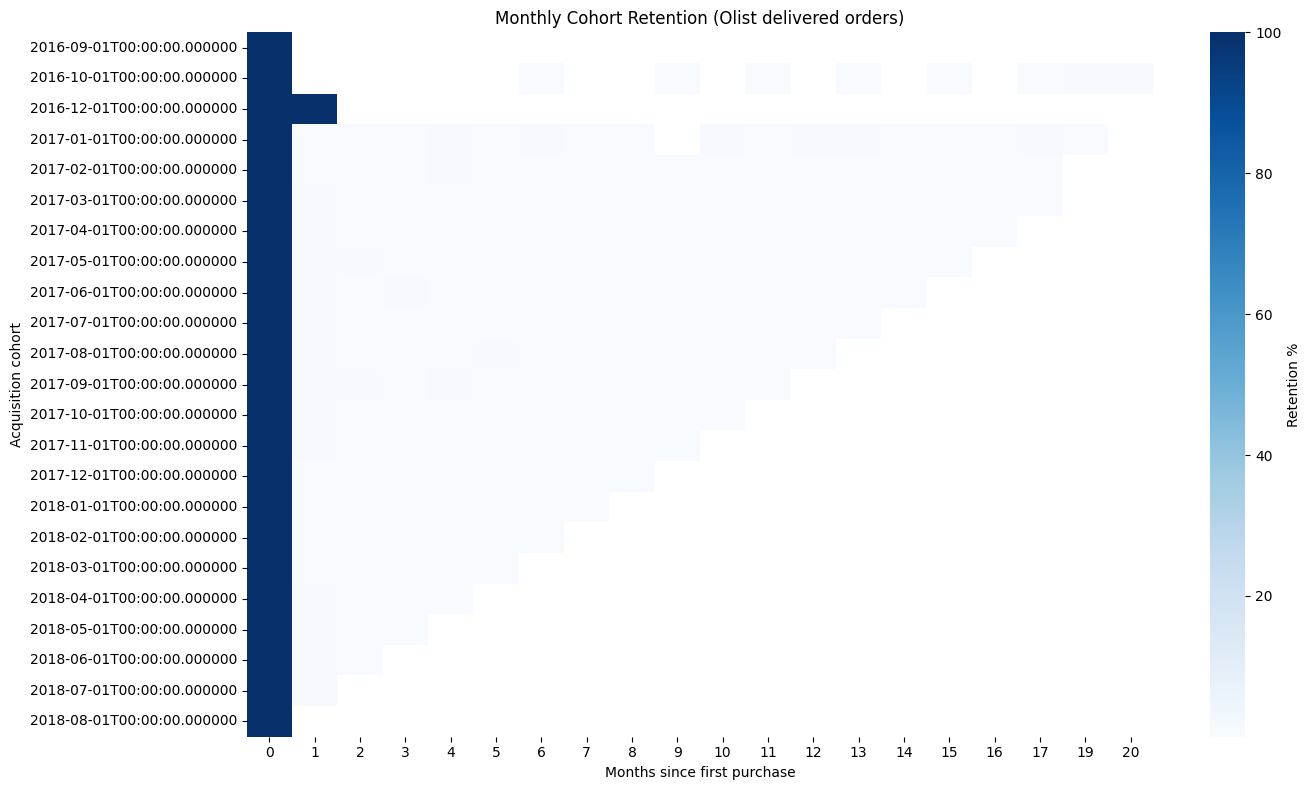

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=False, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "Retention %"})
plt.title("Monthly Cohort Retention (Olist delivered orders)")
plt.xlabel("Months since first purchase")
plt.ylabel("Acquisition cohort")
plt.tight_layout()

In [ ]:
revenue_sql = """
    WITH first_order AS (
        SELECT c.customer_unique_id,
               DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
        FROM orders o JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered' GROUP BY 1
    ),
    monthly_rev AS (
        SELECT c.customer_unique_id,
               DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
               SUM(oi.price + oi.freight_value) AS revenue
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered' GROUP BY 1, 2
    )
    SELECT f.cohort_month,
           DATE_DIFF('month', f.cohort_month, m.order_month) AS month_offset,
           SUM(m.revenue) AS revenue
    FROM first_order f
    JOIN monthly_rev m ON f.customer_unique_id = m.customer_unique_id
    GROUP BY 1, 2 ORDER BY 1, 2
"""
rev_long = run_query(revenue_sql)
print(rev_long.head())
# Revenue per cohort member, cumulative over offsets
rev_pivot = rev_long.pivot(index="cohort_month", columns="month_offset", values="revenue")
clv_per_member = rev_pivot.divide(cohort_sizes, axis=0)
cumulative_clv = clv_per_member.cumsum(axis=1)
cumulative_clv.iloc[:5, :6]

  cohort_month  month_offset   revenue
0   2016-09-01             0    143.46
1   2016-10-01             0  46490.66
2   2016-10-01             6    111.30
3   2016-10-01             9    356.13
4   2016-10-01            11     56.78


month_offset,0,1,2,3,4,5
cohort_month,,,,,,
2016-09-01,143.460000,NaN,NaN,NaN,NaN,NaN
2016-10-01,177.445267,NaN,NaN,NaN,NaN,NaN
2016-12-01,19.620000,39.240000,NaN,NaN,NaN,NaN
2017-01-01,177.772315,177.927225,178.087197,178.212301,178.555746,178.652441
2017-02-01,166.540694,166.836566,167.187076,167.260006,167.967598,168.013182


In [ ]:
# Customer features (RFM + scores) -> drives clustering on Day 16
rfm.to_csv("data/processed/customer_features.csv", index=False)
print(rfm.head())
# Cohort retention matrix -> drives the dashboard cohort page
retention.to_csv("data/processed/cohort_matrix.csv")
print(retention.head())
print("Saved customer_features.csv:", rfm.shape)
print("Saved cohort_matrix.csv:", retention.shape)

                 customer_unique_id  recency_days  frequency  monetary  \
0  639d23421f5517f69d0c3d6e6564cf0e           163          1    157.60   
1  7ed0ea20347f67fe61d1c99fdf8556ae            36          1     97.32   
2  9e4159995424971423b98c4a8bc11529           197          1    126.54   
3  6457be0b331148fb5454efc88d1e03d9           110          1    152.77   
4  f5f088001070650f9e9a8cd773621f35           382          1    112.71   

   avg_order_value      first_purchase       last_purchase  R_score  M_score  \
0           157.60 2018-03-19 18:40:33 2018-03-19 18:40:33        4        4   
1            97.32 2018-07-24 17:04:17 2018-07-24 17:04:17        5        3   
2           126.54 2018-02-13 22:10:21 2018-02-13 22:10:21        3        3   
3           152.77 2018-05-11 20:33:38 2018-05-11 20:33:38        4        4   
4           112.71 2017-08-12 10:08:57 2017-08-12 10:08:57        2        3   

   F_score  RFM_score  
0        1          9  
1        1          9  
2 

In [ ]:
%%writefile sql/02_rfm_metrics.sql
-- 02_rfm_metrics.sql
-- Recency / Frequency / Monetary at customer_unique_id grain.
-- Recency measured from snapshot date 2018-08-29 (dataset max order date).
WITH delivered AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        SUM(oi.price + oi.freight_value) AS order_value
    FROM orders o
    JOIN customers c         ON o.customer_id = c.customer_id
    LEFT JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2, 3
)
SELECT
    customer_unique_id,
    DATE_DIFF('day', MAX(order_purchase_timestamp), DATE '2018-08-29') AS recency_days,
    COUNT(DISTINCT order_id)                                           AS frequency,
    SUM(order_value)                                                  AS monetary,
    AVG(order_value)                                                  AS avg_order_value
FROM delivered
GROUP BY customer_unique_id;

Writing sql/02_rfm_metrics.sql


In [ ]:
%%writefile sql/03_cohort_retention.sql
-- 03_cohort_retention.sql
-- Monthly acquisition cohorts vs active months -> triangular retention.
WITH first_order AS (
    SELECT c.customer_unique_id,
           DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered' GROUP BY 1
),
activity AS (
    SELECT c.customer_unique_id,
           DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered' GROUP BY 1, 2
)
SELECT f.cohort_month,
       DATE_DIFF('month', f.cohort_month, a.order_month) AS month_offset,
       COUNT(DISTINCT a.customer_unique_id) AS active_customers
FROM first_order f
JOIN activity a ON f.customer_unique_id = a.customer_unique_id
GROUP BY 1, 2 ORDER BY 1, 2;

Writing sql/03_cohort_retention.sql


In [ ]:
%%writefile sql/04_clv_aggregations.sql
-- 04_clv_aggregations.sql
-- Revenue per cohort member by month offset -> cumulative cohort CLV.
WITH first_order AS (
    SELECT c.customer_unique_id,
           DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered' GROUP BY 1
),
monthly_rev AS (
    SELECT c.customer_unique_id,
           DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
           SUM(oi.price + oi.freight_value) AS revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered' GROUP BY 1, 2
)
SELECT f.cohort_month,
       DATE_DIFF('month', f.cohort_month, m.order_month) AS month_offset,
       SUM(m.revenue) AS revenue
FROM first_order f
JOIN monthly_rev m ON f.customer_unique_id = m.customer_unique_id
GROUP BY 1, 2 ORDER BY 1, 2;

Writing sql/04_clv_aggregations.sql


In [ ]:
%%writefile src/feature_engineering.py
"""RFM, cohort, and CLV feature engineering for Olist."""
from pathlib import Path
import pandas as pd
from src.data_loader import run_query

SNAPSHOT_DATE = "2018-08-29"


def build_rfm(snapshot_date: str = SNAPSHOT_DATE) -> pd.DataFrame:
    sql = f"""
        WITH delivered AS (
            SELECT c.customer_unique_id, o.order_id,
                   o.order_purchase_timestamp,
                   SUM(oi.price + oi.freight_value) AS order_value
            FROM orders o
            JOIN customers c         ON o.customer_id = c.customer_id
            LEFT JOIN order_items oi ON o.order_id = oi.order_id
            WHERE o.order_status = 'delivered'
            GROUP BY 1, 2, 3
        )
        SELECT customer_unique_id,
               DATE_DIFF('day', MAX(order_purchase_timestamp), DATE '{snapshot_date}') AS recency_days,
               COUNT(DISTINCT order_id) AS frequency,
               SUM(order_value)         AS monetary,
               AVG(order_value)         AS avg_order_value,
               MIN(order_purchase_timestamp) AS first_purchase,
               MAX(order_purchase_timestamp) AS last_purchase
        FROM delivered GROUP BY customer_unique_id
    """
    return run_query(sql)


def add_rfm_scores(rfm: pd.DataFrame) -> pd.DataFrame:
    rfm = rfm.copy()
    rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
    rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5,
                             labels=[1, 2, 3, 4, 5]).astype(int)
    rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
    return rfm


def build_cohort_retention() -> pd.DataFrame:
    sql = Path("sql/03_cohort_retention.sql").read_text()
    long = run_query(sql)
    counts = long.pivot(index="cohort_month", columns="month_offset",
                        values="active_customers")
    return counts.divide(counts[0], axis=0) * 100

Writing src/feature_engineering.py


## Summary — RFM, CLV & Cohort Retention

**Goal:** Build RFM features via SQL, a cohort-based CLV, and the triangular
retention matrix — adapted honestly to a single-purchase dataset.

**What was done**
- Built RFM at `customer_unique_id` grain via SQL (recency from snapshot
  2018-08-29). Saved as `sql/02_rfm_metrics.sql`.
- Scored R, M by quintile; scored F by rank (because >90% of frequency = 1,
  plain quantile binning would fail). F_score is largely cosmetic here and
  kept only for completeness + the rare repeat buyers.
- Built monthly acquisition-cohort retention matrix (`sql/03_cohort_retention.sql`)
  and cohort-based cumulative CLV (`sql/04_clv_aggregations.sql`).
- Wrapped reusable logic into `src/feature_engineering.py`.

**Key findings**
- Customer universe for segmentation: 93,358 customers (slightly below the
  96,096 unique people — RFM joins through order_items, dropping itemless orders).
- Monetary is the strongest usable signal; recency is meaningful; frequency
  is near-constant at 1.
- Retention heatmap is near-empty past month 0 — almost every cohort retains
  <1% in month 1 and beyond. Customers do not come back.

**The narrative this sets up**
- Olist's real problem is not predicting churn but converting one-time buyers.
  We will frame the executive summary and budget allocator around first-purchase
  value and acquisition quality, not retention curves.
- CLV is computed historically (cohort revenue per member, cumulative), NOT via
  a predictive repeat-purchase model that would predict ~zero. This is the
  honest choice and will be stated in limitations.

**Deliverables created**
- `data/processed/customer_features.csv` (93,358 × 11)
- `data/processed/cohort_matrix.csv` (23 cohorts × 20 month-offsets)
- `sql/02_rfm_metrics.sql`, `sql/03_cohort_retention.sql`, `sql/04_clv_aggregations.sql`
- `src/feature_engineering.py`